In [1]:
#################################################################################
# Dynamical Reanalysis Model for Inversions of Temperature: DReamIT             #
#                                                                               #
# === COPYRIGHT AND LICENCE =================================================== #
#                                                                               #
# Copyright 2025 Victor Pozsgay                                                 #
#                                                                               #
#    This program is free software: you can redistribute it and/or modify       #           
#    it under the terms of the GNU General Public License as published by       #
#    the Free Software Foundation, either version 3 of the License, or          #
#    (at your option) any later version.                                        #
#                                                                               #
#    This program is distributed in the hope that it will be useful,            #
#    but WITHOUT ANY WARRANTY; without even the implied warranty of             #
#    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the              #
#    GNU General Public License for more details.                               #
#                                                                               #
#    You should have received a copy of the GNU General Public License          #
#    along with this program.  If not, see <http://www.gnu.org/licenses/>.      #
#                                                                               #
#                                                                               #
# === CONTRIBUTIONS =========================================================== #
#                                                                               #
# Code for ArcticDEM download and hyposmetric calculation written by Victor     #
# Pozsgay. Code for DReaMIT and its integration into GlobSim also done by       #
# Victor Pozsgay. Precious advice for the integration received from Nick Brown. #
#                                                                               #
# ============================================================================= #

# ============================================================================= #
#                                                                               #
# Example file containing: (a) Arctic DEM data download,                        #
#                          (b) Hypsometric calculation from DEM,                #
#                          (c) Reanalysis data download and interpolation at    #
#                              point location.                                  #
#                          (d) Demonstration of the production of DReaMIT model #
#                              surface-based inversion metrics within GlobSim.  #
#                                                                               #
# (1) Get the DReaMIT_demo branch of GlobSim from Github with:                  #
#     git clone --branch DReaMIT_demo --single-branch https://github.com/geocryology/globsim.git #
#                                                                               #
# (2) Create the virtual environment by running:                                #
#     conda env create -f environment.yml                                       #
#                                                                               #
# (3) Install GlobSim with in the root of the GlobSim directory:                #
#     'python -m pip install -e .'                                              #
#                                                                               #
# /!\ OPTIONAL (only if you wish to personally download reanalysis data) /!\    #
# (4) Get personal tokens (credentials) to be able to download ERA5 and JRA-3Q  #
#     data.                                                                     #
#     (a) ERA5:                                                                 #
#         (i) Create a ECMWF account, complete the form, activate your profile, #
#             and go to https://cds-beta.climate.copernicus.eu/how-to-api.      #
#         (ii) Fill the credential file ./user_input/.cdsapirc with your info.  #
#         (iii) Install the CDS API client (pip install 'cdsapi>=0.7.0')        #
#         (iv) go to: https://cds-beta.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels?tab=download #
#              and scroll down a lot and accept the Licence to use Copernicus   #
#               Products under the 'Terms of use'.                              #
#     (b) JRA-3Q:                                                               #
#         (i) Create a GDEX account at https://gdex.ucar.edu/                   #
#         (ii) Go to your Profile>API Token, and copy it into                   #
#              ./user_input/rdams_token.txt                                     #
#     ALL SET!                                                                  #
#                                                                               #
# /!\ OPTIONAL (only if you wish to personally download ArcticDEM data) /!\     #
# (5) Run the 'Download DEM' section of the notebook to download the ArcticDEM  #
#     data for the prescribed point locations, and to compute their hypsometry. #
#                                                                               #
# (6) Run the 'Download ERA5 and JRA-3Q data' section.                          #
#     (a) Download, interpolate, scale: only if you have credentials            #
#     (b) The scaled data will be left available, so you can directly skip to   #
#         STEP 4 and use reanalysis.plotting_from_reanalysis() to explore and   #
#         plot the results of DReaMIT+GlobSim!                                  #
#                                                                               #
# (7) Adapt the script below (settings and location in ./user_input) to try a   #
#     different location, different period, etc.                                #
#                                                                               #
# (8) Customise the code and use it for your project.                           #
#                                                                               #
# (9) Please let us know how things work. We hope this is useful for you.       #
#                                                                               #
# ============================================================================= #

from dem_to_hypso import dem_download
from reanalysis import reanalysis
import pandas as pd

list_reanalysis      = ['era5', 'jra3qg']
formatted_reanalysis = {'era5': 'ERA5', 'jra3qg': 'JRA3QG'}
csv_user_input       = './user_input/config_globsim_pre_hypso.csv'

list_stations        = list(pd.read_csv(csv_user_input)['station_name'])

# Download DEM (arcticdem) and compute hypsometry

In [ ]:
#################################################################################
# This section is only to be run for users willing to compute the hypsometry of #
# a given point. Users who simply wish to use the provided point locations and  #
# correspondng hypsometry can skip to the next section of the notebook.         #
#################################################################################

#################################################################################
# Please note that the code provided here is only designed to download data     #
# from ArcticDEM. For point locations not covered by ArcticDEM, the user will   #
# need to access DEM information in a different way.                            #
#################################################################################

In [2]:
#################################### STEP 1 #####################################
#################################################################################
# Creates a square bounding box for each station (centered around the station   #
# with distance d=52km between the center and the edge of the bounding box).    #
# This is chosen so that we are sure to have at least a 50km radius area to     #
# work with. The created file is found at ./dem_to_hypso/bboxes.csv             #
#################################################################################
dem_download.bboxes(csv_user_input)

In [3]:
#################################### STEP 2 #####################################
#################################################################################
# Creates a list of requests to ArcticDEM server, downloads the files, extracts #
# them to tifs, clips them, and merge them together. At the end, we get the DEM #
# as a panda dataframe object, pickled into their respective folders in         #
# ./DEM_to_hypso.                                                               #
#################################################################################
dem_download.dem_full_download()

Index loaded, total tiles: 2485
Tiles intersecting bbox: 9
No tiles found for dem_res='2m', using available resolution instead.
Extracted 63 DEM TIFFs
Merged DEM saved: ./dem_to_hypso/DMP_WS01/arcticdem_merged.tif
Clipped DEM saved: ./dem_to_hypso/DMP_WS01/arcticdem_clipped.tif
df_grid_DMP_WS01 saved to ./dem_to_hypso/DMP_WS01/df_grid_DMP_WS01.pkl
Index loaded, total tiles: 2485
Tiles intersecting bbox: 8
No tiles found for dem_res='2m', using available resolution instead.
Extracted 56 DEM TIFFs
Merged DEM saved: ./dem_to_hypso/DMP_WS02/arcticdem_merged.tif
Clipped DEM saved: ./dem_to_hypso/DMP_WS02/arcticdem_clipped.tif
df_grid_DMP_WS02 saved to ./dem_to_hypso/DMP_WS02/df_grid_DMP_WS02.pkl


In [2]:
#################################### STEP 3 #####################################
#################################################################################
# Computes the hypsometric position of each station and creates a new csv file  #
# in ./dem_to_hypso/config_globsim_with_hypso.csv with the extra 'hypsometry'   #
# column needed as an input to compute the DReaMIT metrics with GlobSim. We     #
# also produce plots of the DEM for each station, with the stations in the      #
# center and a level line at its corresponding elevation. All plots are saved   #
# as pdf in ./plots, and are also accessed as the result of the following       #
# function.                                                                     #
#################################################################################
figures_DEM = dem_download.hypso_compute_and_plot(list_stations, list_reanalysis)

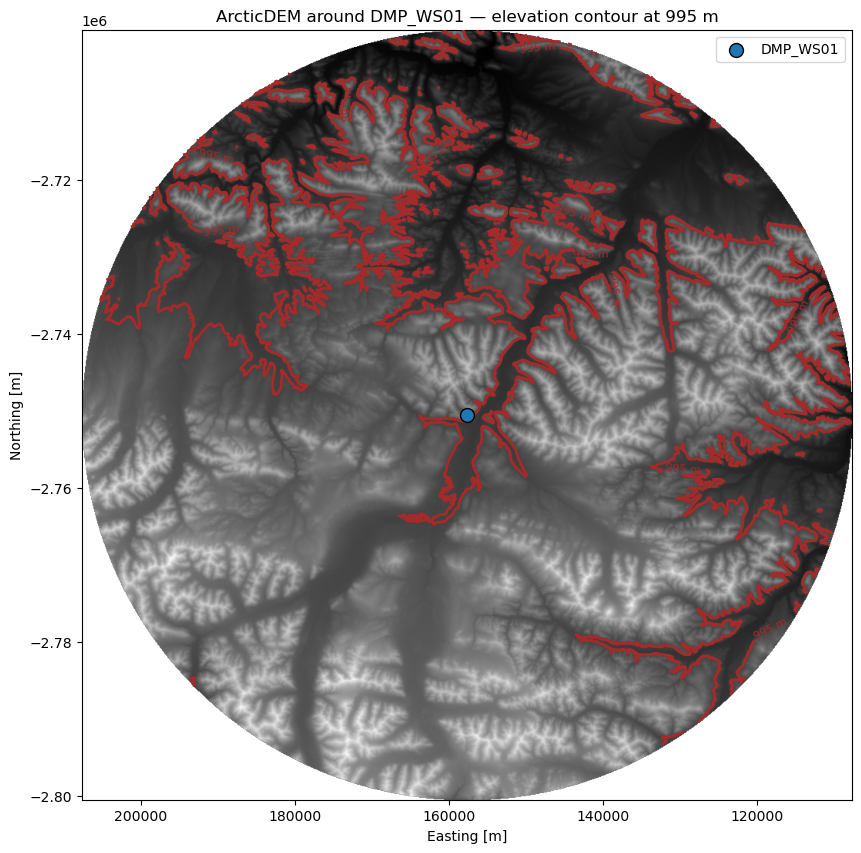

In [3]:
figures_DEM['DMP_WS01']

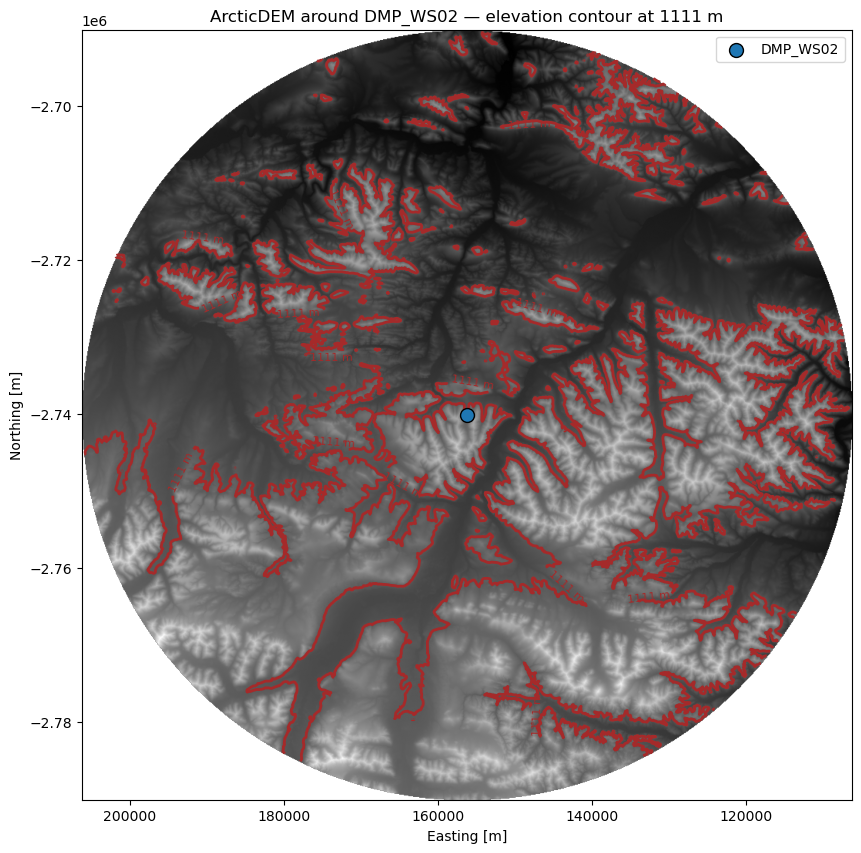

In [4]:
figures_DEM['DMP_WS02']

# Download ERA5 and JRA-3Q data

In [8]:
#################################### STEP 1 #####################################
#################################################################################
# /!\/!\/!\/!\/!\/!\/!\/!\ This operation can be long /!\/!\/!\/!\/!\/!\/!\     #
# Skip and use provided files if you want to save time. Furthermore, you will   #
# NEED to register online and get PERSONAL CREDENTIALS to be able to download   #
# ERA5 and JRA-3Q data.                                                         #
#                                                                               #
# IF YOU HAVE CREDENTIALS, place them into ./user_input/ under the file names:  #
#   - ERA5: .cdsapirc                                                           #
#           url: https://cds.climate.copernicus.eu/api                          #
#           key: XXXXXXXX-XXXX-XXXX-XXXX-XXXXXXXXXXXX                           #
#   - JRA-3Q: rdams_token.txt                                                   #
#             XXXXXXXXXXXXXXXXXXXXXXXXXXXX                                      #
#                                                                               #
# Run this cell to download ERA5 and JRA-3Q data with GlobSim. This notebook    #
# needs to run within the provided conda environment. The user also needs to    #
# have GlobSim downloaded. The downloaded data will be found in ./reanalysis    #
# In each of the era5/ and jra3qg/ folder, you will find 4 netCDF files:        #
#   - to (time invariant quantities),                                           #
#   - sa (single-level accumulation quantities),                                #
#   - sf (single-level flux quantities),                                        #
#   - pl (pressure-level quantities)                                            #
#################################################################################
reanalysis.reanalysis_download(list_reanalysis, formatted_reanalysis)

Starting the ERA5 DOWNLOAD


02:16:23 INFO Bounding box: 64.2 (S) to 65.8 (N) and -139 (W) to -137.4 (E)
02:16:23 WARNING Using optimal monthly chunks.  Chunk size in parameter file ignored.
02:16:23 WARNING Found era5_pl_20230101_to_20230131.nc. Will not re-download.
02:16:23 WARNING Found era5_re_resl_20230101_to_20230131.nc. Will not re-download.
02:16:23 INFO Starting ERA5 multi-threaded download with 6 workers
02:16:23 WARNING Found ['era5_sa_20000101_to_20000101.nc', 'era5_sf_20000101_to_20000101.nc']. Will not re-download.
02:16:23 INFO Finished ERA5 multi-threaded download with 6 workers
02:16:23 INFO Renaming files in ./reanalysis/era5


Skipping reanalysis/era5/era5_to.nc


02:16:26 INFO All files downloaded successfully


None
Serial download finished
ERA5 DOWNLOAD concluded


Starting the JRA3QG DOWNLOAD


...

100.000 % CompletedDownloading 817009.tprate1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_1_52.tprate1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.tprate1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_1_52.tprate1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.dlwrfcs1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_5_8.dlwrfcs1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.dlwrfcs1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_5_8.dlwrfcs1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.dlwrfcs1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_5_8.dlwrfcs1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.dlwrf1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_5_3.dlwrf1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.dlwrf1have-sfc-fc-gauss.jra3q.fcst_phy2m.0_5_3.dlwrf1have-sfc-fc-gauss.2023010100_2023013123.nc
100.000 % CompletedDownloading 817009.dlwrf1

02:21:36 INFO remaining requests :{'POZSGAY817010': 'Queued for Processing', 'POZSGAY817009': 'Completed'}
02:22:12 INFO Geting Active Requets from NCAR Server
02:22:13 INFO Request 817010 Complete


100.000 % CompletedDownloading 817010.ugrd-pres-an-gauss.jra3q.anl_p.0_2_2.ugrd-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.ugrd-pres-an-gauss.jra3q.anl_p.0_2_2.ugrd-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.rh-pres-an-gauss.jra3q.anl_p.0_1_1.rh-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.rh-pres-an-gauss.jra3q.anl_p.0_1_1.rh-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.rh-pres-an-gauss.jra3q.anl_p.0_1_1.rh-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.vgrd-pres-an-gauss.jra3q.anl_p.0_2_3.vgrd-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.vgrd-pres-an-gauss.jra3q.anl_p.0_2_3.vgrd-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.vgrd-pres-an-gauss.jra3q.anl_p.0_2_3.vgrd-pres-an-gauss.2023010100_2023010518.nc
100.000 % CompletedDownloading 817010.tmp-pres-an-gauss.jra3

02:22:53 INFO remaining requests :{'POZSGAY817010': 'Completed'}
02:22:53 INFO All requests processed
02:22:53 INFO 817007: Done
02:22:53 INFO 817008: Done
02:22:53 INFO 817009: Done
02:22:53 INFO 817010: Done
02:22:53 INFO Download Completed
02:22:53 INFO jra3qg Complete


None
Serial download finished
JRA3QG DOWNLOAD concluded




In [9]:
#################################### STEP 2 #####################################
#################################################################################
# Run this cell to interpolate ERA5 and JRA-3Q data with GlobSim. The resulting #
# files are interpolated at the stations' location and elevation. We still have #
# the same netCDF files (to, sa, sf, pl), with the addition of pl_surface.      #
#################################################################################
reanalysis.reanalysis_interpolate(list_reanalysis, formatted_reanalysis)

Starting the ERA5 INTERPOLATION


02:25:44 INFO Creating new file reanalysis/era5/interpolated/era5_to_config_globsim_with_hypso.nc from 
02:25:44 INFO Source dataset is 2D (without pressure levels)
02:25:44 INFO Created new empty variable: lsm [(0 - 1)]
02:25:44 INFO Created new empty variable: z [m**2 s**-2]
02:25:45 INFO era5_to_config_globsim_with_hypso.nc -- 2000-01-01 00:00:00 to 2000-01-01 00:00:00
02:25:45 INFO Memory usage: 2.40 GB (7.6%)
02:25:45 INFO Creating new file reanalysis/era5/interpolated/era5_sa_config_globsim_with_hypso.nc from 
02:25:45 INFO Source dataset is 2D (without pressure levels)
02:25:45 INFO Created new empty variable: d2m [K]
02:25:45 INFO Created new empty variable: t2m [K]
02:25:45 INFO Created new empty variable: tco3 [kg m**-2]
02:25:45 INFO Created new empty variable: tcwv [kg m**-2]
02:25:45 INFO Created new empty variable: u10 [m s**-1]
02:25:45 INFO Created new empty variable: v10 [m s**-1]
02:25:45 INFO era5_sa_config_globsim_with_hypso.nc -- 2023-01-01 00:00:00 to 2023-01-05 2

ERA5 INTERPOLATION concluded


Starting the JRA3QG INTERPOLATION


02:25:47 INFO Check data integrity (sa)
02:25:47 INFO Check data integrity (sf)
02:25:47 INFO Check data integrity (pl)
02:25:47 INFO Data integrity ok
02:25:47 INFO Creating new file reanalysis/jra3qg/interpolated/jra3qg_to_config_globsim_with_hypso.nc from 
02:25:47 INFO Source dataset is 2D (without pressure levels)
02:25:47 INFO Created new empty variable: Geopotential [m2 s-2]
02:25:47 INFO jra3qg_to_config_globsim_with_hypso.nc -- 1947-09-01 00:00:00 to 1947-09-01 00:00:00
02:25:47 INFO Memory usage: 2.42 GB (7.7%)
02:25:47 INFO Creating new file reanalysis/jra3qg/interpolated/jra3qg_sa_config_globsim_with_hypso.nc from 
02:25:47 INFO Source dataset is 2D (without pressure levels)
02:25:47 INFO Created new empty variable: Temperature [K]
02:25:47 INFO Created new empty variable: Relative humidity [percent]
02:25:47 INFO Created new empty variable: Specific humidity [kg kg-1]
02:25:47 INFO Created new empty variable: v-component of wind [m s-1]
02:25:47 INFO Created new empty vari

JRA3QG INTERPOLATION concluded




In [2]:
#################################### STEP 3 #####################################
#################################################################################
# Run this cell to scale ERA5 and JRA-3Q data with GlobSim. The resulting files #
# are scaled at the stations' location and elevation. We still have the same    #
# netCDF files as the interpolated step (see STEP 2 above). The scaled netCDF   #
# files' variables include:                                                     #
#   - AIRT_pl(time, station): air_temperature pressure levels only [C]          #
#   - AIRT_sur(time, station): 2_metre_temperature surface only [C]             #
# The following variables are new with the DReaMIT -> GlobSim integration       #
#   - AIRT_DReaMIT_C(time_station): DReaMIT model air temperature corrected for #
#     surface-based inversions [C]                                              #
#   - z_top_inversion_m(time, station): Top of inversion elevation [m]          #
#   - T_lapse_grid_C(time_station): Temperature at grid level if solely         #
#     determined by dynamically-computed linear lapse rate [C]                  #
#   - T_lapse_station_C(time_station): Temperature at station level if solely   #
#     determined by dynamically-computed linear lapse rate [C]                  #
#   - lapse_Cperm(time_station): Lower atmosphere dynamically-computed linear   #
#     lapse rate [C m-1]                                                        #
#                                                                               #
# Other variables are available for the user with the inclusion of more kernels #
# under the [scale] section of the GlobSim TOML configuration file              #
#################################################################################
reanalysis.reanalysis_scale(list_reanalysis, formatted_reanalysis)

Starting the ERA5 SCALING


20:51:09 WARNING Missing snow correction factor parameter in control file. Reverting to default (scf = 1).
20:51:09 WARNING Missing relative humidity approximation choice in control file (rh_approximation). Reverting to default ('rh_liston').
20:51:09 WARNING No station_name variable in interpolated netCDF.
20:51:09 WARNING One or more station names in interpolated netCDF are missing. Matching stations based on station number and coordinates only.
20:51:09 WARNING  DMP_WS01 site elevation (997 m) is below reanalysis grid elevation (1213.336820550341 m). Results may be unreliable.
20:51:09 WARNING  DMP_WS02 site elevation (1109 m) is below reanalysis grid elevation (1142.3115946831997 m). Results may be unreliable.
20:51:09 INFO running scaling kernel: 'AIRT_C_pl'
20:51:09 INFO running scaling kernel: 'AIRT_C_sur'
20:51:09 INFO running scaling kernel: 'AIRT_DReaMIT'
20:51:09 INFO Created scaled output file /home/vpo001/globsim/DReaMIT_demo/reanalysis/era5/scaled/scaled_era5_1h_scf1.nc


ERA5 SCALING concluded


Starting the JRA3QG SCALING


20:51:10 WARNING Missing snow correction factor parameter in control file. Reverting to default (scf = 1).
20:51:10 WARNING Missing relative humidity approximation choice in control file (rh_approximation). Reverting to default ('rh_liston').
20:51:10 WARNING No station_name variable in interpolated netCDF.
20:51:10 WARNING One or more station names in interpolated netCDF are missing. Matching stations based on station number and coordinates only.
20:51:11 WARNING  DMP_WS01 site elevation (997 m) is below reanalysis grid elevation (1202.176703754595 m). Results may be unreliable.
20:51:11 WARNING  DMP_WS02 site elevation (1109 m) is below reanalysis grid elevation (1145.698068243233 m). Results may be unreliable.
20:51:11 INFO running scaling kernel: 'AIRT_C_pl'
20:51:11 INFO running scaling kernel: 'AIRT_C_sur'
20:51:11 INFO running scaling kernel: 'AIRT_DReaMIT'
20:51:11 INFO Created scaled output file /home/vpo001/globsim/DReaMIT_demo/reanalysis/jra3qg/scaled/scaled_jra3qg_1h_scf1.n

JRA3QG SCALING concluded




In [3]:
#################################### STEP 4 #####################################
#################################################################################
# Run this cell to view ERA5 and JRA-3Q data with GlobSim. This creates a pdf   #
# plot per ranalysis and per station.  Each plot is a 2x2 subplot, with:        #
#   - first axis: air temperatures (pressure-level, surface, and DReaMIT model) #
#   - second axis: lapse air temperatures (at grid and station elevations)      #
#   - third axis: top of inversion elevation                                    #
#   - fourth axis: lapse rate                                                   #
# The function also returns the plots directly as a dictionary, and they can be #
# opened in this notebook.                                                      #
#################################################################################
figures_scaled = reanalysis.plotting_from_reanalysis(list_reanalysis,
                                                     formatted_reanalysis)

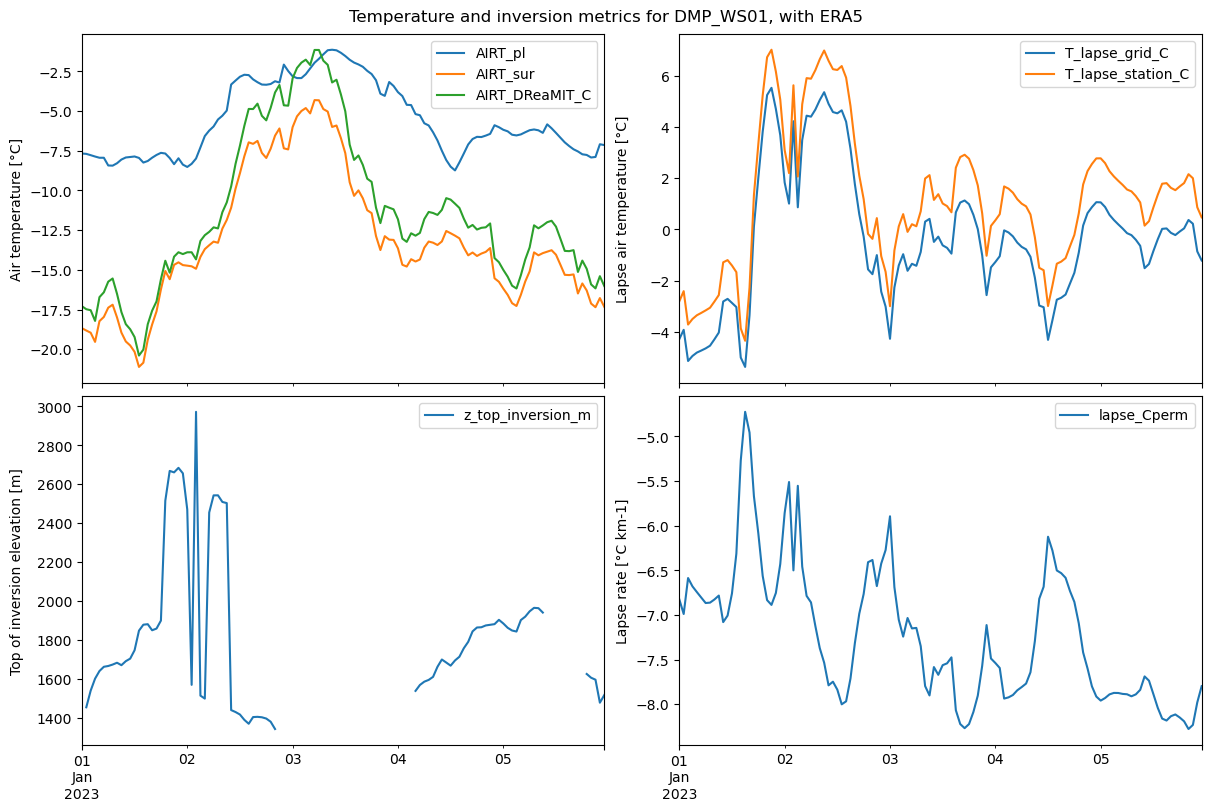

In [8]:
figures_scaled['era5']['DMP_WS01']